# Marketing Campaign Performance Analysis

Analysis of multi-channel campaign performance, built on the Snowflake
marketing warehouse. This notebook connects to the warehouse, pulls the
campaign and channel rollups plus the daily performance fact, and explores
return on ad spend, spend efficiency over time, and the conversion funnel.

## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "semibold"

from snowflake.connector import connect
from cryptography.hazmat.primitives import serialization


SNOWFLAKE_ACCOUNT = "account_identifier"
SNOWFLAKE_USER    = "ABIGAILKEEGAN"
PRIVATE_KEY_PATH  = "rsa_key.p8"


with open(PRIVATE_KEY_PATH, "rb") as f:
    private_key = serialization.load_pem_private_key(f.read(), password=None)

pkb = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption(),
)

conn = connect(
    account=SNOWFLAKE_ACCOUNT,
    user=SNOWFLAKE_USER,
    private_key=pkb,
    warehouse="COMPUTE_WH",
    database="MARKETING_WAREHOUSE",
    schema="ANALYTICS",
)

def q(sql):
    """Run a query and return a DataFrame."""
    cur = conn.cursor()
    try:
        cur.execute(sql)
        return cur.fetch_pandas_all()
    finally:
        cur.close()


## Load Data

In [7]:
channel = q("SELECT * FROM VW_CHANNEL_SUMMARY")
campaign = q("SELECT * FROM VW_CAMPAIGN_SUMMARY")

daily = q("""
    SELECT p.DATE_DAY, p.SPEND, p.REVENUE, p.CONVERSIONS,
           p.CLICKS, p.IMPRESSIONS, c.CHANNEL, c.CAMPAIGN_NAME
    FROM FACT_CAMPAIGN_PERFORMANCE p
    JOIN DIM_CAMPAIGN c ON p.CAMPAIGN_KEY = c.CAMPAIGN_KEY
""")
daily["DATE_DAY"] = pd.to_datetime(daily["DATE_DAY"])

print(f"{len(daily):,} daily rows across {campaign.shape[0]} campaigns and {channel.shape[0]} channels")
campaign.head()


408 daily rows across 12 campaigns and 4 channels


,CAMPAIGN_KEY,CAMPAIGN_NAME,CHANNEL,TOTAL_SPEND,TOTAL_REVENUE,TOTAL_CONVERSIONS,TOTAL_CLICKS,TOTAL_IMPRESSIONS,ROAS,CTR,CPC,CONVERSION_RATE
0,1,Winter Gift Guide 2010,Email,8500.00,57406.27,120,6907.0,254825.0,6.75,0.0271,1.23,0.0174
1,11,Back to School 2011,Display,8000.00,24831.71,63,5042.0,250726.0,3.10,0.0201,1.59,0.0125
2,6,Halloween Push 2010,Social,5399.89,31415.41,89,4949.0,229305.0,5.82,0.0216,1.09,0.0180
3,3,Mother's Day Promo 2010,Social,6500.00,12309.26,45,5821.0,254016.0,1.89,0.0229,1.12,0.0077
4,8,Valentine's 2011,Display,5999.91,10393.51,37,4279.0,199790.0,1.73,0.0214,1.40,0.0086


## 1. Return on ad spend by channel


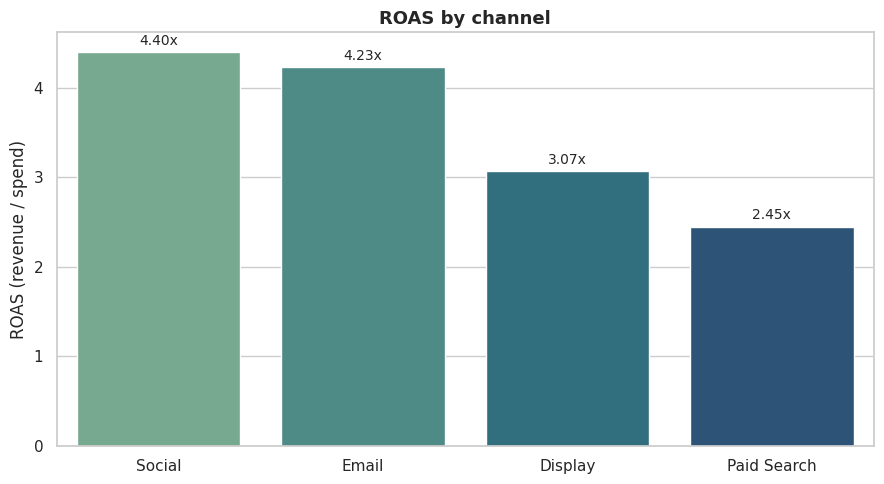

In [8]:
ch = channel.sort_values("ROAS", ascending=False)

ax = sns.barplot(data=ch, x="CHANNEL", y="ROAS", hue="CHANNEL", palette="crest", legend=False)
ax.set_title("ROAS by channel")
ax.set_xlabel("")
ax.set_ylabel("ROAS (revenue / spend)")
for i, v in enumerate(ch["ROAS"]):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


## 2. Spend vs revenue over time

Daily spend and revenue summed across all campaigns, with a 7-day moving
average on revenue to smooth the noise.

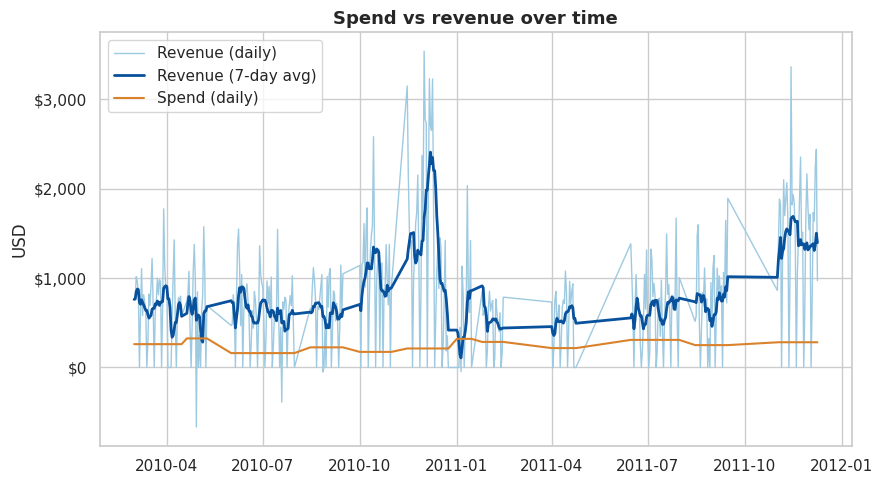

In [9]:
ts = (daily.groupby("DATE_DAY")[["SPEND", "REVENUE"]]
            .sum()
            .sort_index())
ts["REVENUE_7D"] = ts["REVENUE"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(ts.index, ts["REVENUE"], color="#9ecae1", linewidth=1, label="Revenue (daily)")
ax.plot(ts.index, ts["REVENUE_7D"], color="#08519c", linewidth=2, label="Revenue (7-day avg)")
ax.plot(ts.index, ts["SPEND"], color="#d9822b", linewidth=1.5, label="Spend (daily)")
ax.set_title("Spend vs revenue over time")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


## 3. Campaign ROAS ranking

The same metric at the campaign level, sorted so the strongest and weakest campaigns are obvious. Bars are colored by channel to show whether strong performance clusters in particular channels.

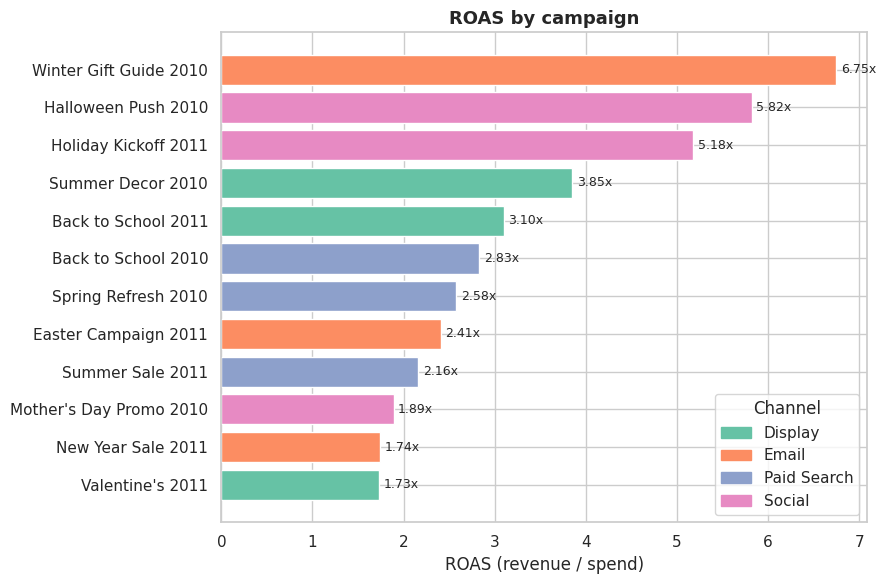

In [10]:
cp = campaign.sort_values("ROAS", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
palette = dict(zip(sorted(cp["CHANNEL"].unique()),
                   sns.color_palette("Set2", cp["CHANNEL"].nunique())))
colors = cp["CHANNEL"].map(palette)
ax.barh(cp["CAMPAIGN_NAME"], cp["ROAS"], color=colors)
ax.set_title("ROAS by campaign")
ax.set_xlabel("ROAS (revenue / spend)")
for i, v in enumerate(cp["ROAS"]):
    ax.text(v + 0.05, i, f"{v:.2f}x", va="center", fontsize=9)
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[c]) for c in palette]
ax.legend(handles, palette.keys(), title="Channel", loc="lower right")
plt.tight_layout()
plt.show()


## 4. Conversion funnel


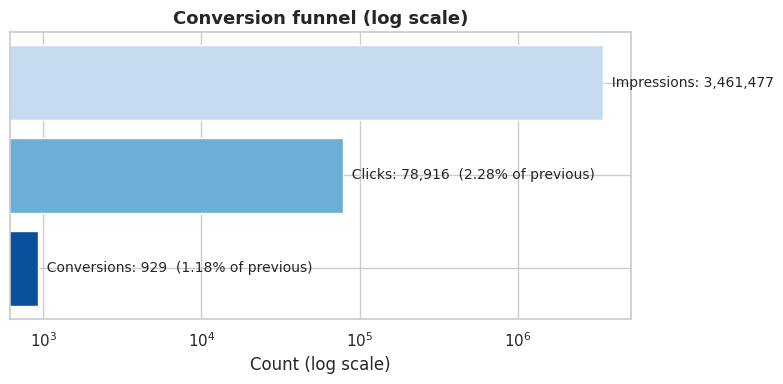

In [11]:
imp = daily["IMPRESSIONS"].sum()
clk = daily["CLICKS"].sum()
cnv = daily["CONVERSIONS"].sum()

stages = ["Impressions", "Clicks", "Conversions"]
values = [imp, clk, cnv]
rates = [None, clk / imp, cnv / clk]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c6dbef", "#6baed6", "#08519c"]
for i, (s, v) in enumerate(zip(stages, values)):
    ax.barh(i, v, color=colors[i])
    label = f"{s}: {v:,.0f}"
    if rates[i] is not None:
        label += f"  ({rates[i]*100:.2f}% of previous)"
    ax.text(v, i, "  " + label, va="center", fontsize=10)
ax.set_yticks(range(len(stages)))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_title("Conversion funnel (log scale)")
ax.set_xlabel("Count (log scale)")
plt.tight_layout()
plt.show()


## 5. Spend vs revenue relationship

Each point is a campaign. The dashed line is break-even (revenue equals
spend); points above it returned more than they cost. Point size reflects
conversions.

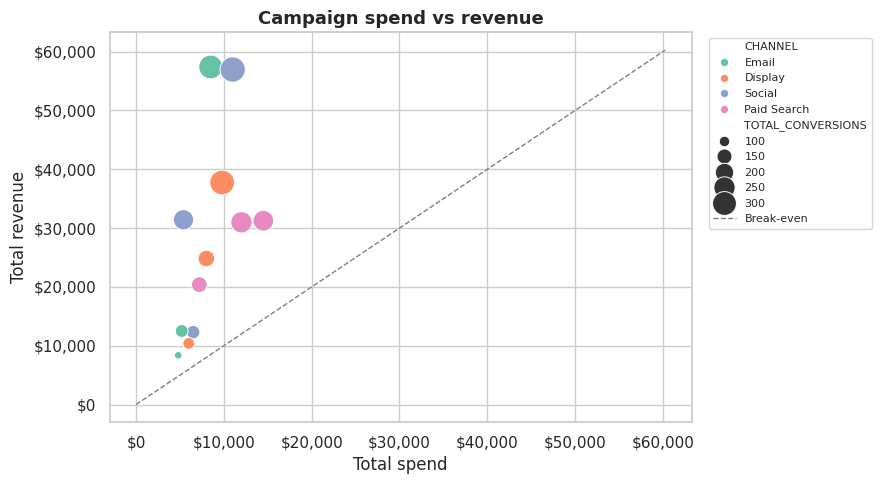

In [12]:
fig, ax = plt.subplots()
sizes = (campaign["TOTAL_CONVERSIONS"] / campaign["TOTAL_CONVERSIONS"].max()) * 300 + 30
sns.scatterplot(data=campaign, x="TOTAL_SPEND", y="TOTAL_REVENUE",
                hue="CHANNEL", size=sizes, sizes=(30, 330),
                legend="brief", ax=ax, palette="Set2")
lim = max(campaign["TOTAL_SPEND"].max(), campaign["TOTAL_REVENUE"].max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="grey", linewidth=1, label="Break-even")
ax.set_title("Campaign spend vs revenue")
ax.set_xlabel("Total spend")
ax.set_ylabel("Total revenue")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## Findings

The program is net positive overall. Total revenue of about 335K USD against roughly 99K USD in spend gives a blended ROAS near 3.4x, and the time series shows daily revenue running consistently above a nearly flat spend line.

Social and Email are the most efficient channels. Social returns 4.40x and Email 4.23x, close to double Paid Search at 2.45x, with Display in between at 3.07x.

The largest budget is going to the least efficient channel. Paid Search has the highest total spend of any channel (about 33,700 USD across three campaigns) but the lowest ROAS. Summer Sale 2011 alone took the single largest budget at \14,500 USD and returned only 2.16x. On its face this points to shifting budget away from Paid Search toward Social and Email.

Channel performance is partly confounded by timing. The strongest campaigns (Winter Gift Guide, Holiday Kickoff, Halloween Push) all run into the holiday season, where the time series shows revenue spiking every November and December. The weakest (New Year, Valentine's, Mother's Day) run in the post-holiday lull. So ROAS here may reflect when a campaign ran as much as which channel it used, and a fair comparison would control for seasonality before naming a channel winner.

Channel averages hide campaign-level spread. Email contains both the single best campaign (Winter Gift Guide, 6.75x) and one of the weakest (New Year Sale, around 1.7x), so a blended channel number can mislead on its own.

The clicks-to-conversions step is where efficiency is lost.Tens of thousands of clicks produced around 929 conversions across the program. If the goal were to lift returns without raising spend, conversion rate is the lever to pull, not impressions or clicks.


In [13]:
conn.close()